# 04 — 2.5D Pipeline Validation (Phase 5)

## Objective
Verify that the 5-slice (z−2 … z+2, 1 mm apart) 2.5D inputs are correct — slice order, boundaries, annotation alignment — and quantify what the extra slices add over a single 2D slice. Results come from `python scripts/validate_25d.py` (`data/metadata/25d_validation.json`).

## Configuration

In [1]:
import json
from pathlib import Path
META = Path('../data/metadata'); FIG = Path('../results/figures')

## Imports

In [2]:
import pandas as pd
from IPython.display import Image, display
res = json.loads((META/'25d_validation.json').read_text())

## A. Cache integrity and slice order
Cached patches were compared bit-for-bit with an independent re-extraction (pad-then-crop with clamped slice indices) from freshly preprocessed scans. A reversed-channel control must *not* match.

In [3]:
a = res['A_B_integrity_boundary']
pd.Series({'patches checked': a['integrity_checked'], 'exact match with independent reference': a['integrity_exact_match'], 'reversed-order control differs': a['reversed_order_differs_from_cache']}).to_frame('count')

,count
patches checked,37
exact match with independent reference,37
reversed-order control differs,37


## B. Boundary handling
Slices beyond the scan ends replicate the edge slice (`boundary: edge`). Boundary cases are rare: candidates within 2 slices of a scan end exist but none are nodules.

In [4]:
print('near scan end per split:', a['candidates_near_scan_end'], '| positives near end:', a['positives_near_scan_end'])
pd.Series(res['B_all_boundary_candidates']).to_frame('count')

near scan end per split: {'train': 19, 'val': 0, 'test': 0} | positives near end: 0


,count
candidates_checked,19
match_independent_reference,19
edge_replication_correct,19


## C. Annotation alignment (all 1,557 positives)

In [5]:
c = res['C_D_alignment_and_comparison']
pd.Series({k: c[k] for k in ['positives','boxes_present_frac','box_inside_patch_frac','nodule_centre_within_window_frac']}).to_frame('value')

,value
positives,1557.000000
boxes_present_frac,1.000000
box_inside_patch_frac,1.000000
nodule_centre_within_window_frac,0.842646


In [6]:
pd.DataFrame({'box offset from patch centre (px)': c['box_offset_px'], '|nodule z − candidate z| (mm)': c['abs_dz_mm']})

,box offset from patch centre (px),|nodule z − candidate z| (mm)
median,0.845469,0.551513
p95,8.407604,5.703039
max,12.731841,14.756179


In [7]:
print('Centre-slice contrast (nodule core − surrounding ring):', c['centre_slice_contrast_nodule_minus_ring'])

Centre-slice contrast (nodule core − surrounding ring): {'median': 0.44824519753456116, 'frac_positive': 0.9922928709055877}


Every box lies inside the patch and 99.2% of nodule cores are brighter than their surroundings (the rest are likely ground-glass or juxtapleural). For 84% of positives the nodule centre lies inside the 5-slice window; the others are large nodules whose candidate sits off-centre in z yet still inside the nodule.

## Samples: 5 channels with the box target

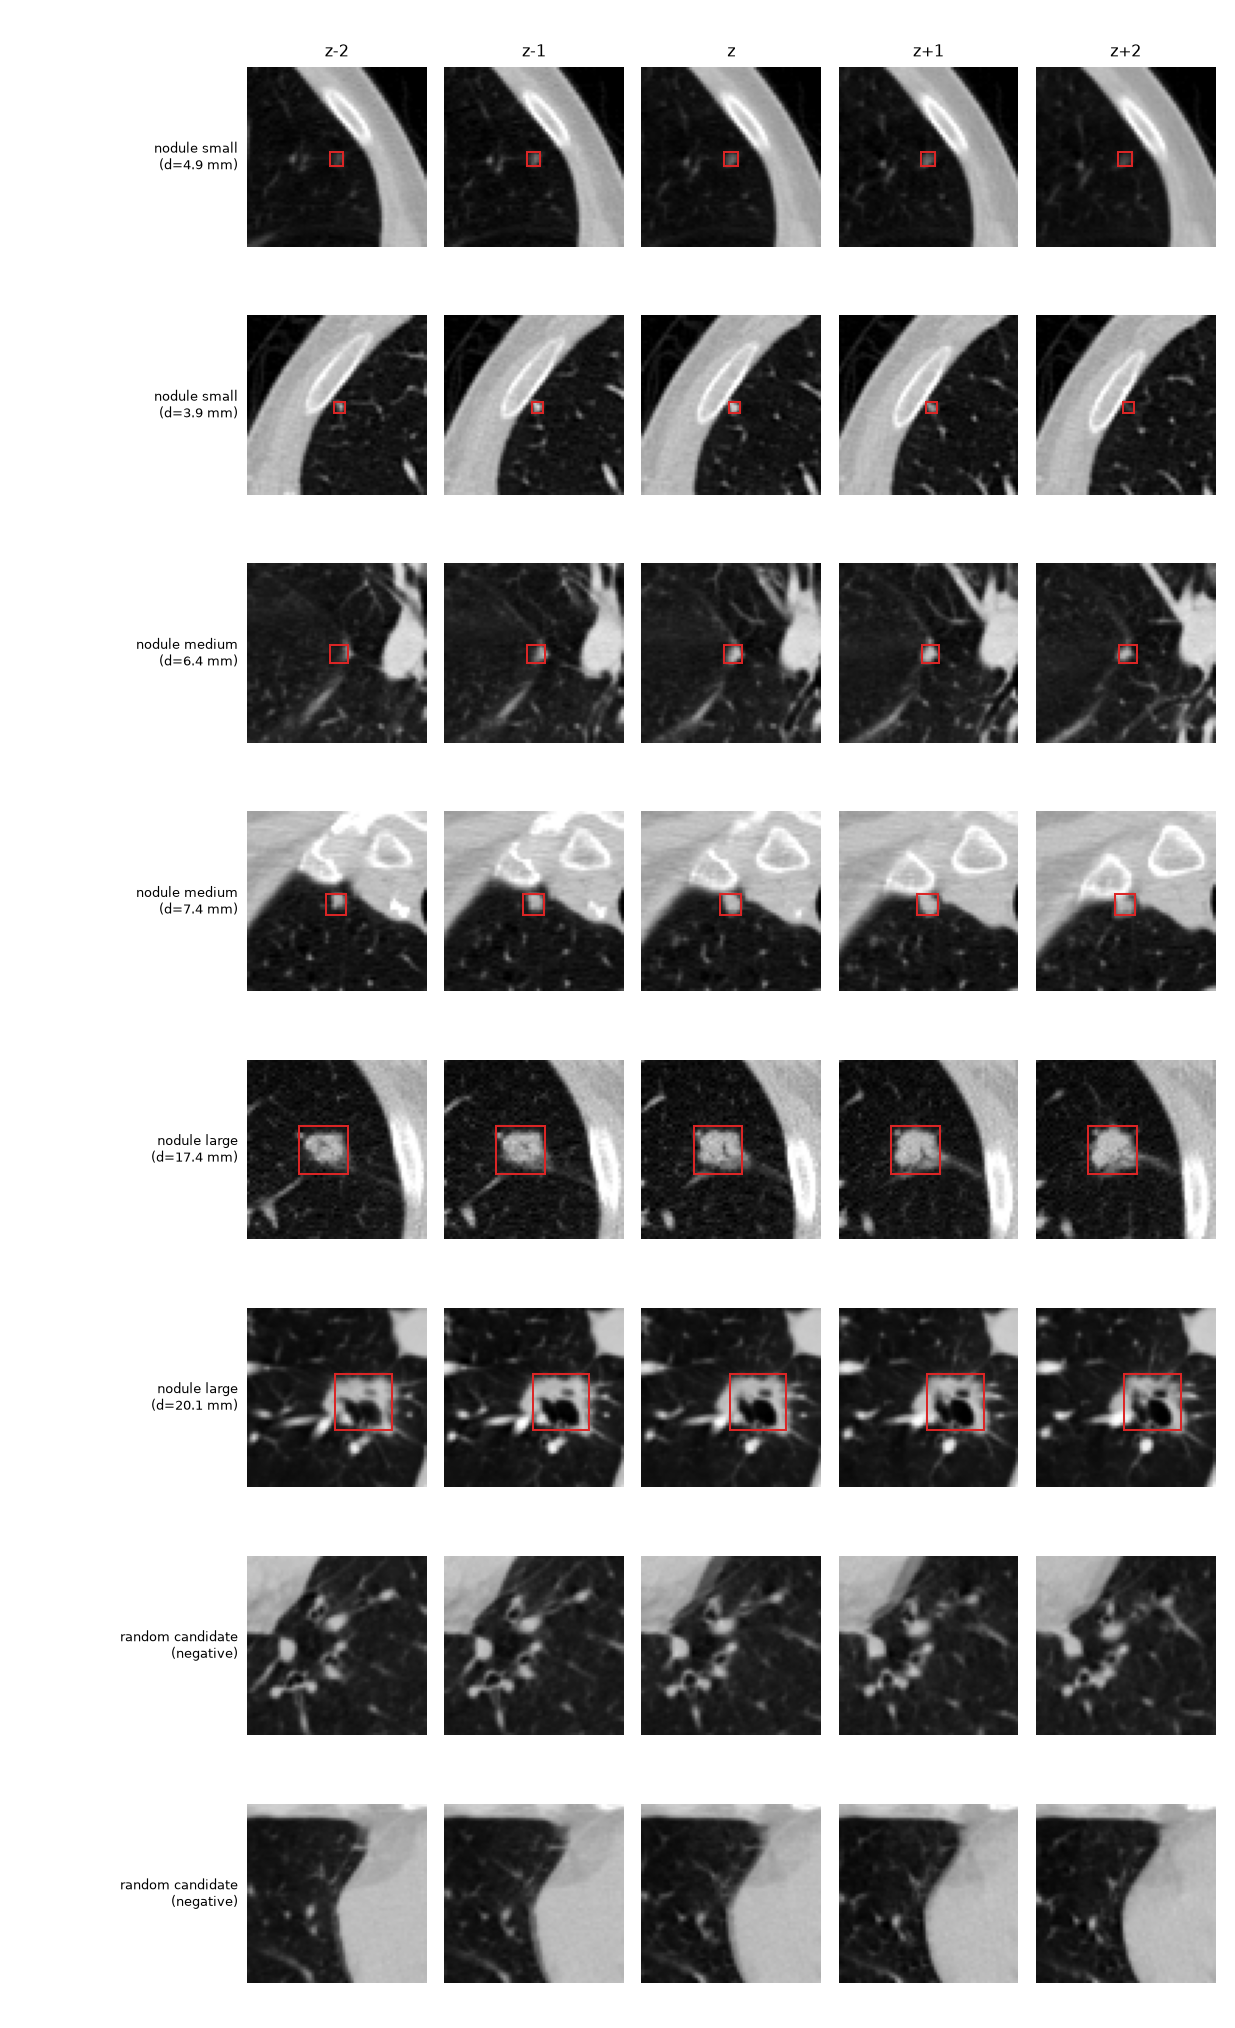

In [8]:
display(Image(FIG/'exp000_25d_samples.png', width=620))

## D. 2D vs 2.5D input comparison

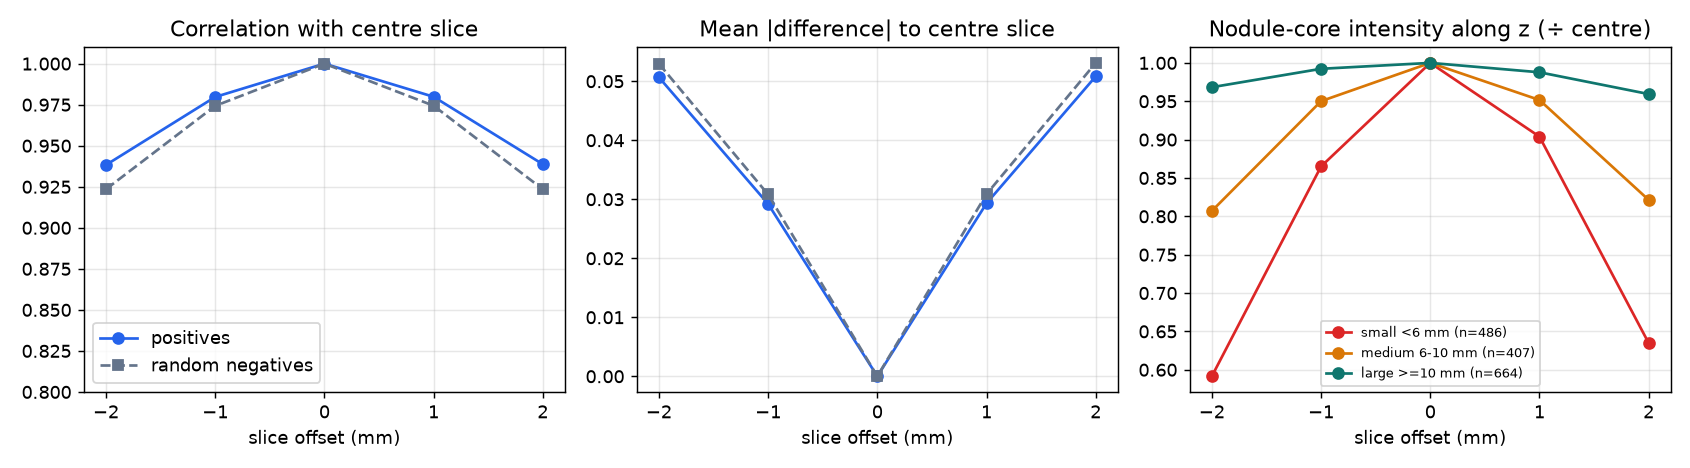

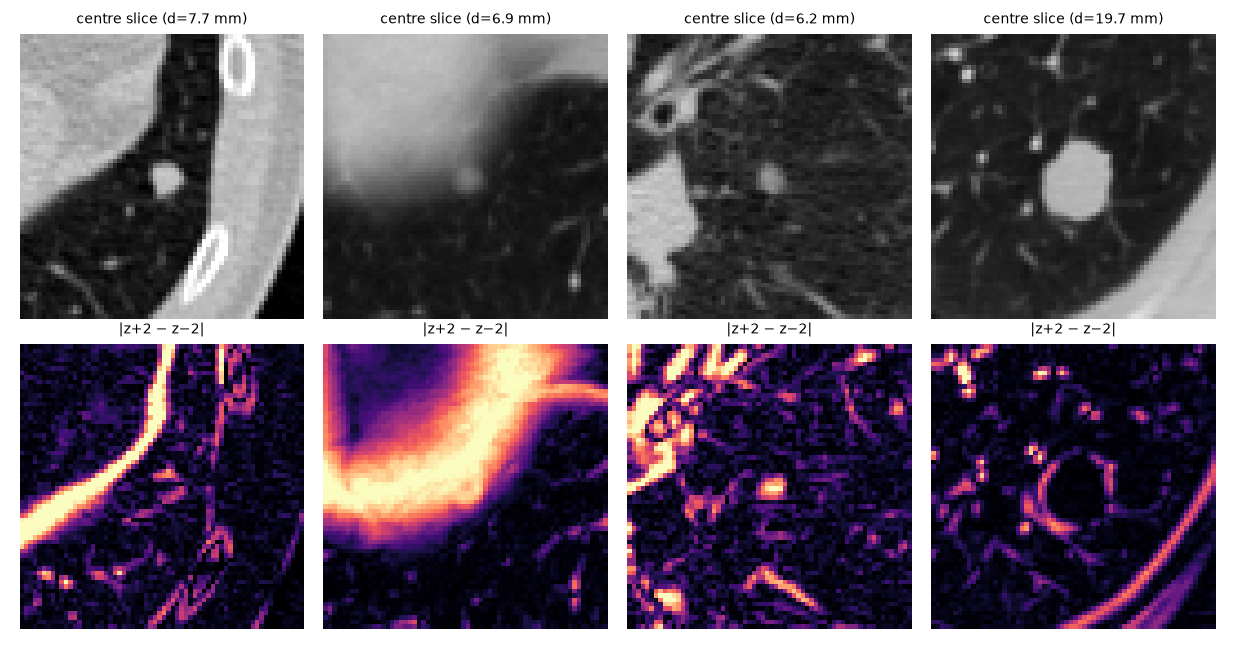

In [9]:
display(Image(FIG/'exp000_25d_channel_stats.png'))
display(Image(FIG/'exp000_25d_difference.png', width=640))

In [10]:
pd.DataFrame(c['nodule_profile_by_size'], index=['n','mean_profile']).T

,n,mean_profile
small <6 mm,486,"[0.3685, 0.5389, 0.623, 0.5631, 0.3955]"
medium 6-10 mm,407,"[0.5273, 0.6208, 0.6534, 0.6218, 0.5367]"
large >=10 mm,664,"[0.6415, 0.6574, 0.6625, 0.6544, 0.6356]"


## Findings
* Adjacent 1 mm slices are highly correlated (0.98 at ±1, 0.94 at ±2), so the channels are redundant for most structure — as expected visually.
* For **small nodules** (<6 mm) the core intensity falls to ~60% of the centre value at ±2 mm, and for medium nodules to ~80%; large nodules are nearly constant. The extra slices therefore carry shape/extent information exactly where nodules are hardest.
* This is an *input-level* observation only. Whether it improves detection is tested in Phase 6 (2D vs 2.5D CNN, and 1 vs 3 vs 5 slices) — not assumed.

## Conclusion
The 2.5D pipeline reproduces independent extraction exactly, handles scan boundaries, and keeps annotations aligned. Phase 5 completion criteria met.